In [2]:
import sqlite3
import pandas as pd
from datetime import datetime

print("Expense Tracker Started")


Expense Tracker Started


In [3]:
conn = sqlite3.connect("expenses.db")
cursor = conn.cursor()

cursor.execute("""
CREATE TABLE IF NOT EXISTS expenses (
    id INTEGER PRIMARY KEY AUTOINCREMENT,
    date TEXT NOT NULL,
    category TEXT NOT NULL,
    description TEXT,
    amount REAL NOT NULL
)
""")

conn.commit()

print("Database and expenses table created successfully!")


Database and expenses table created successfully!


In [5]:
def add_expense(category, description, amount, date=None):
    if date is None:
        date = datetime.now().strftime("%Y-%m-%d")
    
    cursor.execute("""
    INSERT INTO expenses (date, category, description, amount)
    VALUES (?, ?, ?, ?)
    """, (date, category, description, amount))
    
    conn.commit()
    print("Expense added successfully!")



In [6]:
sample_expenses = [
    ("Food", "Lunch", 150),
    ("Travel", "Bus", 60),
    ("Education", "Python Course", 499),
    ("Food", "Snacks", 80),
    ("Entertainment", "Movie", 250),
    ("Travel", "Auto", 120),
    ("Education", "Book", 350),
    ("Food", "Dinner", 200)
]

for category, description, amount in sample_expenses:
    add_expense(category, description, amount)

print("Sample data added!")


Expense added successfully!
Expense added successfully!
Expense added successfully!
Expense added successfully!
Expense added successfully!
Expense added successfully!
Expense added successfully!
Expense added successfully!
Sample data added!


In [7]:
def view_expenses():
    query = "SELECT * FROM expenses ORDER BY date DESC"
    df = pd.read_sql_query(query, conn)
    return df

view_expenses()


,id,date,category,description,amount
0,1,2026-10-02,Food,Lunch,150.0
1,2,2026-10-02,Travel,Bus,60.0
2,3,2026-10-02,Education,Python Course,499.0
3,4,2026-10-02,Food,Snacks,80.0
4,5,2026-10-02,Entertainment,Movie,250.0
5,6,2026-10-02,Travel,Auto,120.0
6,7,2026-10-02,Education,Book,350.0
7,8,2026-10-02,Food,Dinner,200.0


In [8]:
add_expense(
    category="Food",
    description="Coffee",
    amount=100
)

view_expenses()


Expense added successfully!


,id,date,category,description,amount
0,1,2026-10-02,Food,Lunch,150.0
1,2,2026-10-02,Travel,Bus,60.0
2,3,2026-10-02,Education,Python Course,499.0
3,4,2026-10-02,Food,Snacks,80.0
4,5,2026-10-02,Entertainment,Movie,250.0
5,6,2026-10-02,Travel,Auto,120.0
6,7,2026-10-02,Education,Book,350.0
7,8,2026-10-02,Food,Dinner,200.0
8,9,2026-10-02,Food,Coffee,100.0


In [9]:
query = """
SELECT SUM(amount) AS total_spending
FROM expenses
"""

result = pd.read_sql_query(query, conn)

print(f"Total Spending: ₹{result['total_spending'][0]:.2f}")


Total Spending: ₹1809.00


In [10]:
query = """
SELECT category, 
       COUNT(*) AS number_of_expenses,
       SUM(amount) AS total_spending
FROM expenses
GROUP BY category
ORDER BY total_spending DESC
"""

category_summary = pd.read_sql_query(query, conn)

category_summary


,category,number_of_expenses,total_spending
0,Education,2,849.0
1,Food,4,530.0
2,Entertainment,1,250.0
3,Travel,2,180.0


In [11]:
query = """
SELECT *
FROM expenses
ORDER BY amount DESC
LIMIT 5
"""

top_expenses = pd.read_sql_query(query, conn)

top_expenses


,id,date,category,description,amount
0,3,2026-10-02,Education,Python Course,499.0
1,7,2026-10-02,Education,Book,350.0
2,5,2026-10-02,Entertainment,Movie,250.0
3,8,2026-10-02,Food,Dinner,200.0
4,1,2026-10-02,Food,Lunch,150.0


In [12]:
def search_category(category):
    query = """
    SELECT *
    FROM expenses
    WHERE category = ?
    ORDER BY amount DESC
    """
    
    return pd.read_sql_query(query, conn, params=(category,))

search_category("Food")


,id,date,category,description,amount
0,8,2026-10-02,Food,Dinner,200.0
1,1,2026-10-02,Food,Lunch,150.0
2,9,2026-10-02,Food,Coffee,100.0
3,4,2026-10-02,Food,Snacks,80.0


In [13]:
query = """
SELECT substr(date, 1, 7) AS month,
       SUM(amount) AS total_spending
FROM expenses
GROUP BY month
ORDER BY month
"""

monthly_summary = pd.read_sql_query(query, conn)

monthly_summary


,month,total_spending
0,2026-10,1809.0


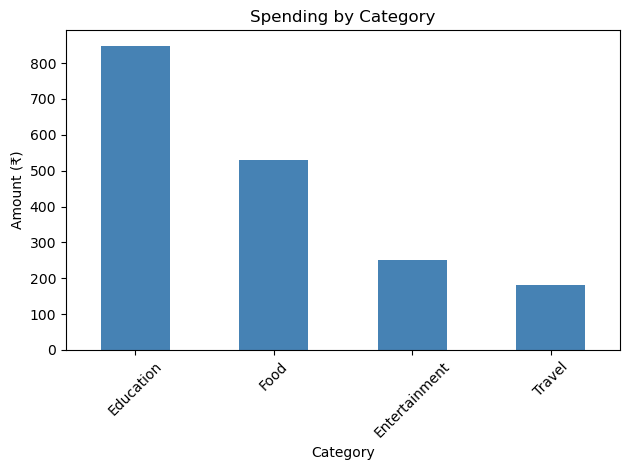

In [14]:
import matplotlib.pyplot as plt

category_summary.plot(
    x="category",
    y="total_spending",
    kind="bar",
    color="steelblue",
    legend=False
)

plt.title("Spending by Category")
plt.xlabel("Category")
plt.ylabel("Amount (₹)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [15]:
def update_expense(expense_id, new_category, new_description, new_amount):
    cursor.execute("""
    UPDATE expenses
    SET category = ?, description = ?, amount = ?
    WHERE id = ?
    """, (new_category, new_description, new_amount, expense_id))
    
    conn.commit()
    print("Expense updated successfully!")

# Example
update_expense(1, "Food", "Lunch at restaurant", 200)

view_expenses()


Expense updated successfully!


,id,date,category,description,amount
0,1,2026-10-02,Food,Lunch at restaurant,200.0
1,2,2026-10-02,Travel,Bus,60.0
2,3,2026-10-02,Education,Python Course,499.0
3,4,2026-10-02,Food,Snacks,80.0
4,5,2026-10-02,Entertainment,Movie,250.0
5,6,2026-10-02,Travel,Auto,120.0
6,7,2026-10-02,Education,Book,350.0
7,8,2026-10-02,Food,Dinner,200.0
8,9,2026-10-02,Food,Coffee,100.0


In [16]:
def delete_expense(expense_id):
    cursor.execute("""
    DELETE FROM expenses
    WHERE id = ?
    """, (expense_id,))
    
    conn.commit()
    print("Expense deleted successfully!")

# Example:
# delete_expense(1)

view_expenses()


,id,date,category,description,amount
0,1,2026-10-02,Food,Lunch at restaurant,200.0
1,2,2026-10-02,Travel,Bus,60.0
2,3,2026-10-02,Education,Python Course,499.0
3,4,2026-10-02,Food,Snacks,80.0
4,5,2026-10-02,Entertainment,Movie,250.0
5,6,2026-10-02,Travel,Auto,120.0
6,7,2026-10-02,Education,Book,350.0
7,8,2026-10-02,Food,Dinner,200.0
8,9,2026-10-02,Food,Coffee,100.0


In [17]:
print("PERSONAL EXPENSE TRACKER & SPENDING ANALYZER")
print("=" * 50)

total = pd.read_sql_query(
    "SELECT SUM(amount) AS total FROM expenses", conn
)["total"][0]

count = pd.read_sql_query(
    "SELECT COUNT(*) AS count FROM expenses", conn
)["count"][0]

print(f"Total Transactions : {count}")
print(f"Total Spending     : ₹{total:.2f}")

print("\nCategory Summary:")
display(category_summary)


PERSONAL EXPENSE TRACKER & SPENDING ANALYZER
Total Transactions : 9
Total Spending     : ₹1859.00

Category Summary:


,category,number_of_expenses,total_spending
0,Education,2,849.0
1,Food,4,530.0
2,Entertainment,1,250.0
3,Travel,2,180.0
